In [1]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs



### Load Scores

In [2]:
month_idx = 4

In [3]:
scores_Log_trasform = model.shape_data.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Log_transform", name=f"month_idx = {month_idx}",name_postfix="back_transformed")

In [4]:
scores_gamma = model.shape_data.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/gamma", name=f"month_idx = {month_idx}",name_postfix="")

In [5]:
scores_beta_approx2 = model.shape_data.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx2_month_idx = {month_idx}", name_postfix="back_transformed")

In [6]:
scores_beta_approx_emp11 = model.shape_data.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx_emp11_month_idx = {month_idx}", name_postfix="back_transformed")

In [7]:
scores_beta_approx_mon_emp11 = model.shape_data.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx_mon_emp11_month_idx = {month_idx}", name_postfix="back_transformed")

Text(0.5, 1.0, 'crpss_score against const mean')

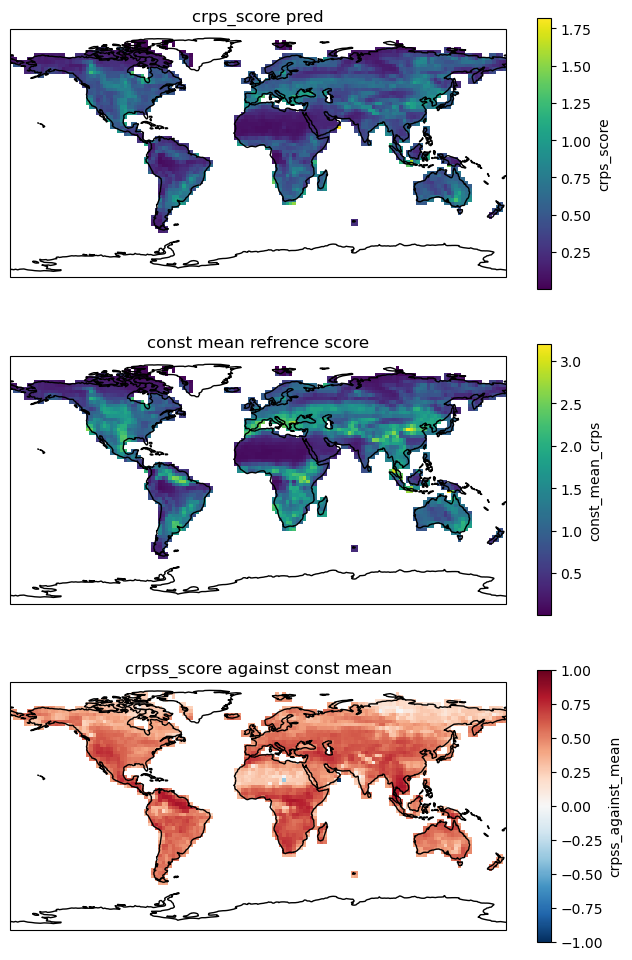

In [8]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores_Log_trasform.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores_Log_trasform.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores_Log_trasform.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'crpss_score against const mean')

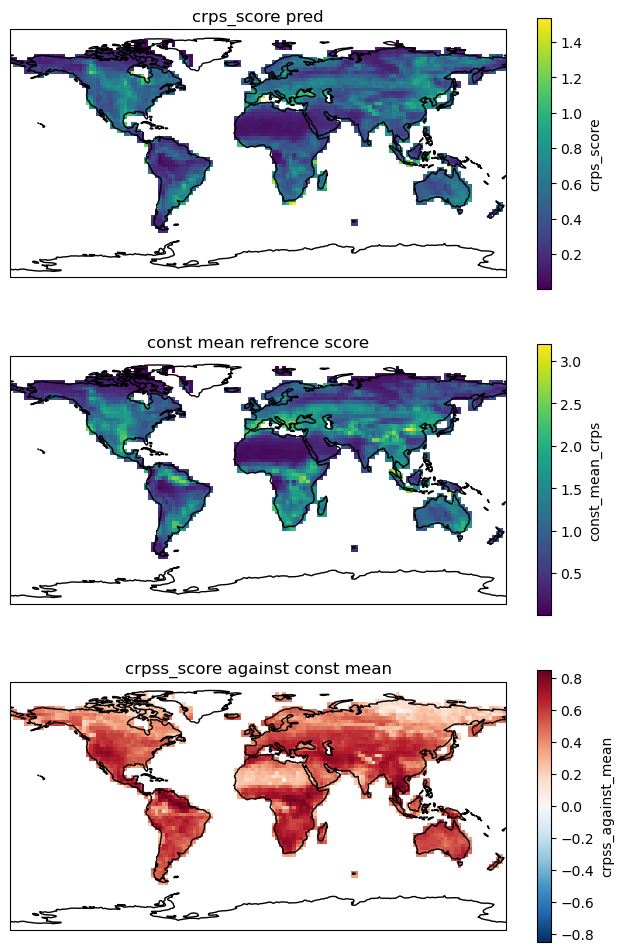

In [9]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores_gamma.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores_gamma.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores_gamma.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")


Text(0.5, 1.0, 'crpss_score against const mean')

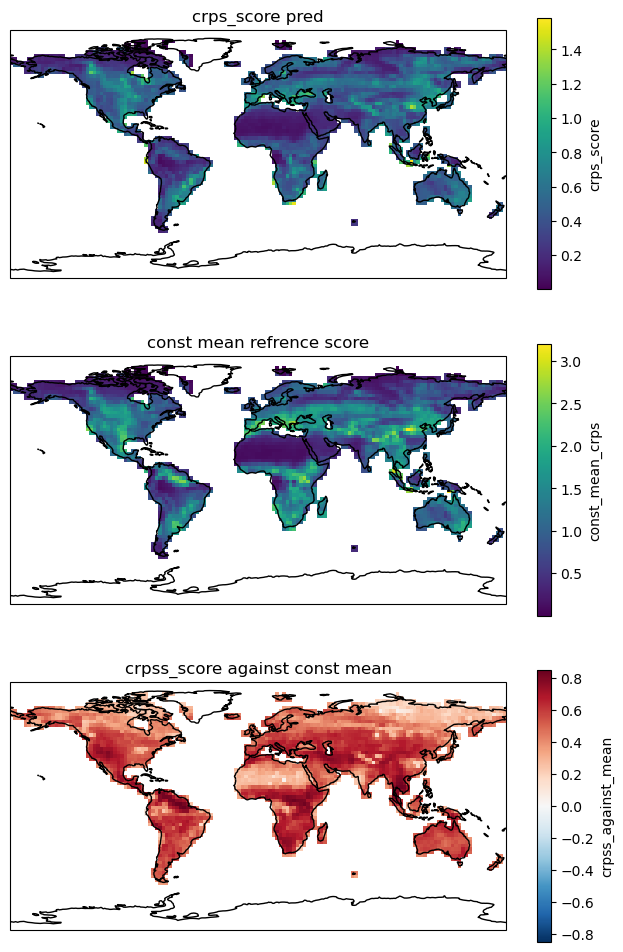

In [10]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores_beta_approx2.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores_beta_approx2.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores_beta_approx2.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")


Text(0.5, 1.0, 'crpss_score against const mean')

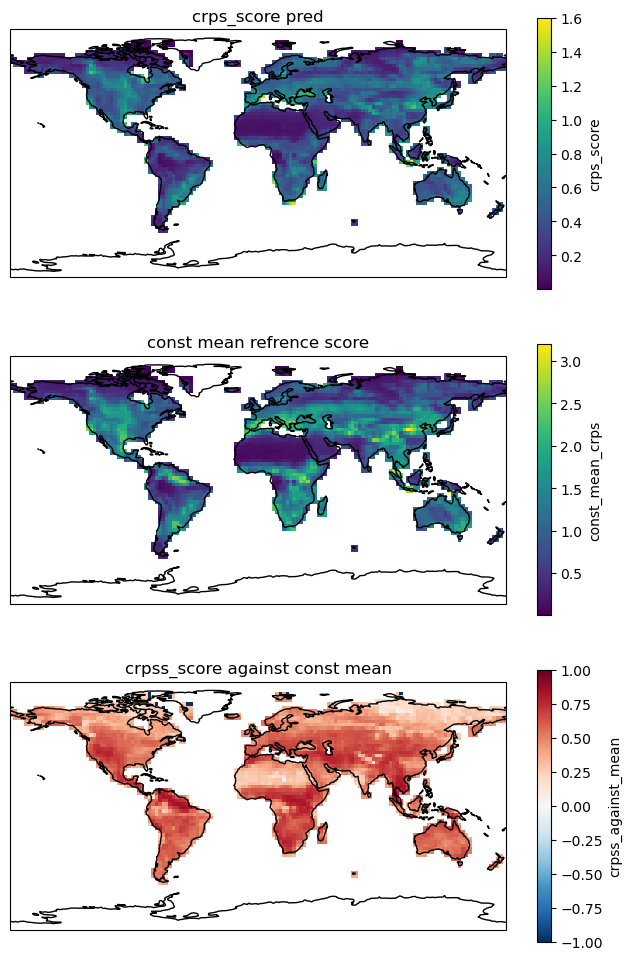

In [11]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores_beta_approx_emp11.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores_beta_approx_emp11.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores_beta_approx_emp11.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")


In [12]:
gamma_vs_Log = model_analysis.crps_score.combine_two_crps_and_the_crpss(scores_gamma.crps_score,scores_Log_trasform.crps_score,"gamma","Log")

In [13]:
beta_2_vs_Log = model_analysis.crps_score.combine_two_crps_and_the_crpss(scores_beta_approx2.crps_score,scores_Log_trasform.crps_score,"beta_2","Log")

/home/pjunghans/BachelorArbeit/model_analysis/crps_score.py:240: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  combined_crps = xr.concat([crps_score_1, crps_score_2], dim="model")


In [14]:
beta_emp_vs_Log = model_analysis.crps_score.combine_two_crps_and_the_crpss(scores_beta_approx_emp11.crps_score,scores_Log_trasform.crps_score,"beta_emp","Log")

/home/pjunghans/BachelorArbeit/model_analysis/crps_score.py:240: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  combined_crps = xr.concat([crps_score_1, crps_score_2], dim="model")


In [15]:
beta_emp_vs_gamma = model_analysis.crps_score.combine_two_crps_and_the_crpss(scores_beta_approx_emp11.crps_score,scores_gamma.crps_score,"beta_emp","gamma")

/home/pjunghans/BachelorArbeit/model_analysis/crps_score.py:240: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  combined_crps = xr.concat([crps_score_1, crps_score_2], dim="model")


In [16]:
beta_emp_vs_beta_2 = model_analysis.crps_score.combine_two_crps_and_the_crpss(scores_beta_approx_emp11.crps_score,scores_beta_approx2.crps_score,"beta_emp","beta_2")

In [17]:
beta_emp_vs_beta_mon_emp = model_analysis.crps_score.combine_two_crps_and_the_crpss(scores_beta_approx_emp11.crps_score,scores_beta_approx_mon_emp11.crps_score,"beta_emp","beta_mon_emp")

Text(0.5, 1.0, 'crpss_score Log against gamma')

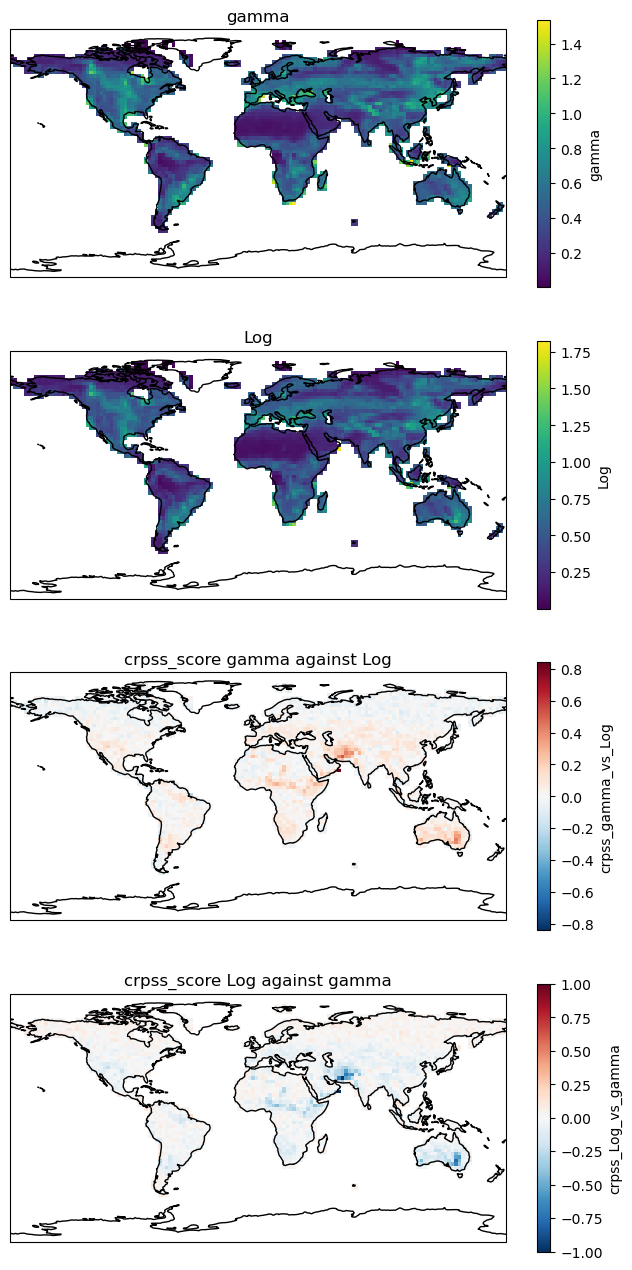

In [18]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
)
depth = 0

da = gamma_vs_Log.isel(depth=depth).mean("time").gamma.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("gamma")

da = gamma_vs_Log.isel(depth=depth).mean("time").Log
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("Log")

da = gamma_vs_Log.isel(depth=depth).crpss_gamma_vs_Log.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score gamma against Log")

da = gamma_vs_Log.isel(depth=depth).crpss_Log_vs_gamma.clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title("crpss_score Log against gamma")


Text(0.5, 1.0, 'crpss_score Log against beta 2')

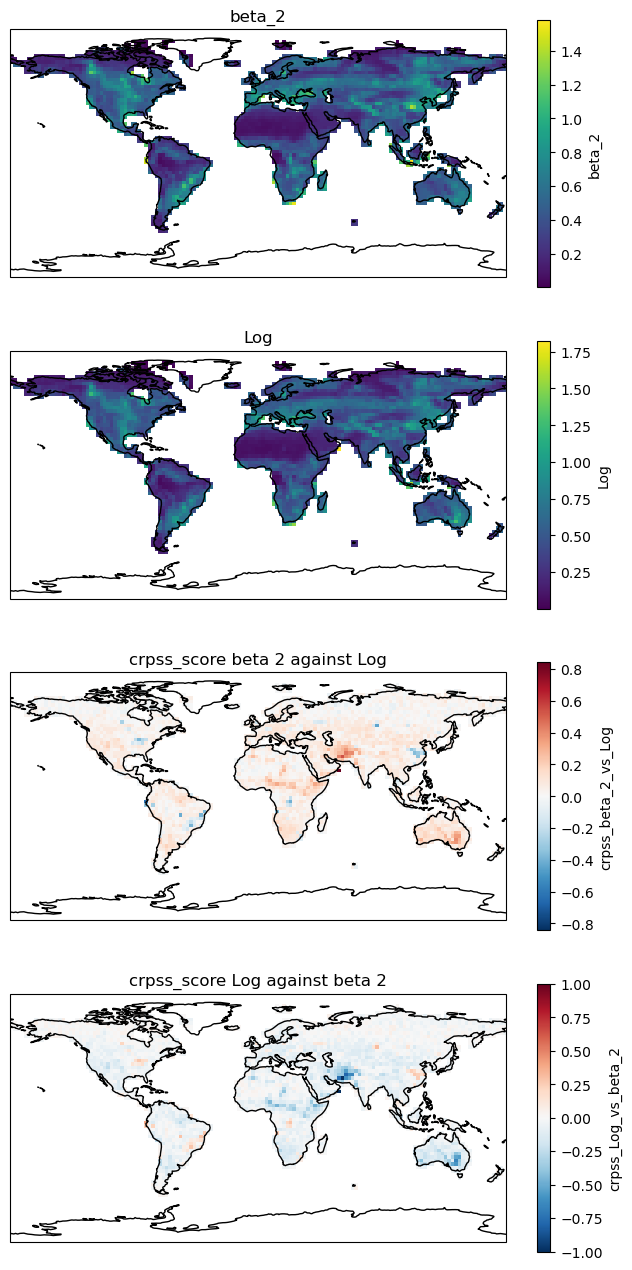

In [19]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
)
depth = 0

da = beta_2_vs_Log.isel(depth=depth).mean("time").beta_2.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("beta_2")

da = beta_2_vs_Log.isel(depth=depth).mean("time").Log
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("Log")

da = beta_2_vs_Log.isel(depth=depth).crpss_beta_2_vs_Log.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score beta 2 against Log")

da = beta_2_vs_Log.isel(depth=depth).crpss_Log_vs_beta_2.clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title("crpss_score Log against beta 2")


Text(0.5, 1.0, 'crpss_score Log against beta emp')

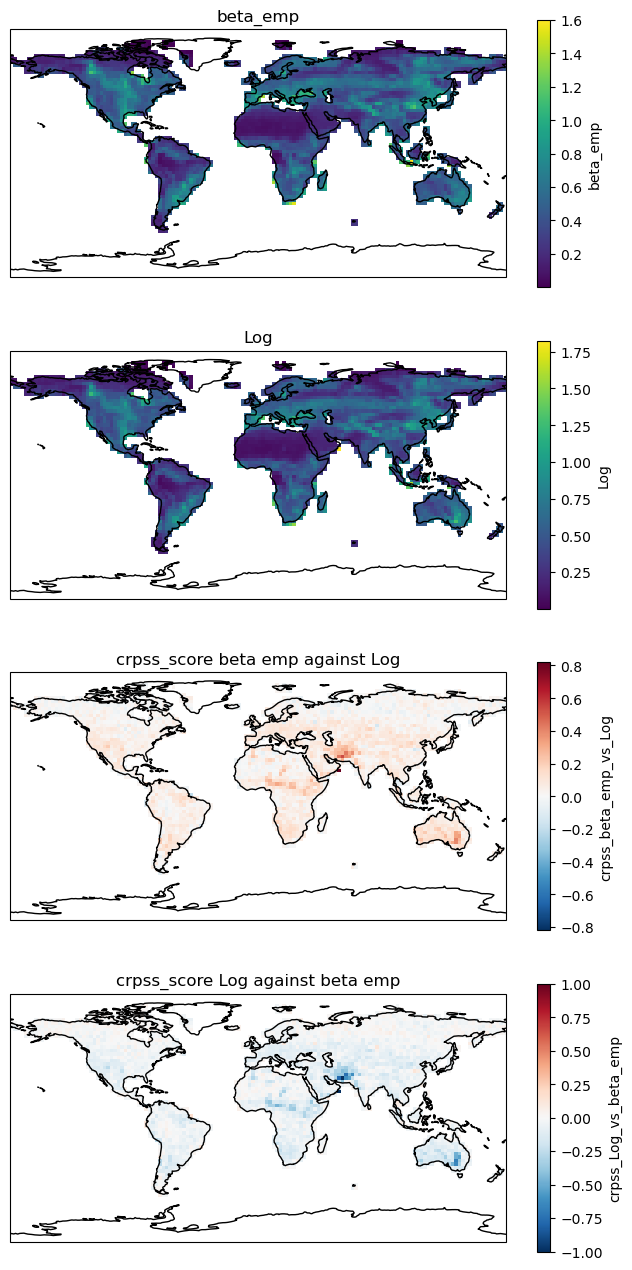

In [20]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
)
depth = 0

da = beta_emp_vs_Log.isel(depth=depth).mean("time").beta_emp.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("beta_emp")

da = beta_emp_vs_Log.isel(depth=depth).mean("time").Log
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("Log")

da = beta_emp_vs_Log.isel(depth=depth).crpss_beta_emp_vs_Log.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score beta emp against Log")

da = beta_emp_vs_Log.isel(depth=depth).crpss_Log_vs_beta_emp.clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title("crpss_score Log against beta emp")


Text(0.5, 1.0, 'crpss_score gamma against beta emp')

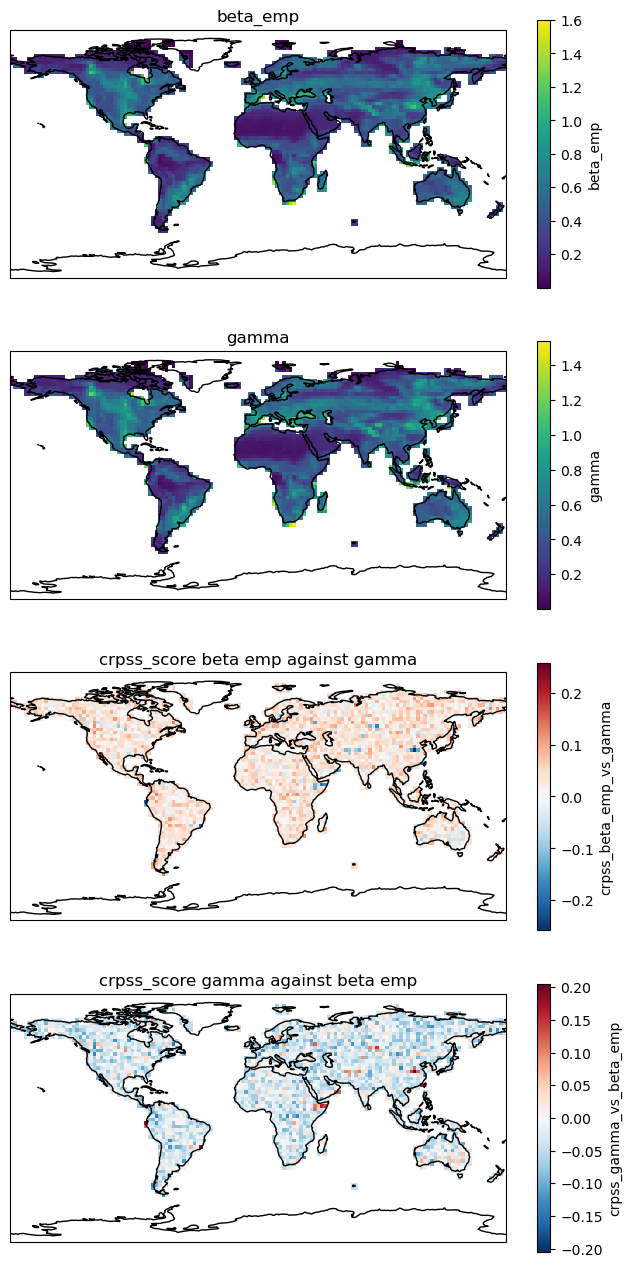

In [21]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
)
depth = 0

da = beta_emp_vs_gamma.isel(depth=depth).mean("time").beta_emp.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("beta_emp")

da = beta_emp_vs_gamma.isel(depth=depth).mean("time").gamma
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("gamma")

da = beta_emp_vs_gamma.isel(depth=depth).crpss_beta_emp_vs_gamma.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score beta emp against gamma")

da = beta_emp_vs_gamma.isel(depth=depth).crpss_gamma_vs_beta_emp.clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title("crpss_score gamma against beta emp")


Text(0.5, 1.0, 'crpss_score beta_2 against beta emp')

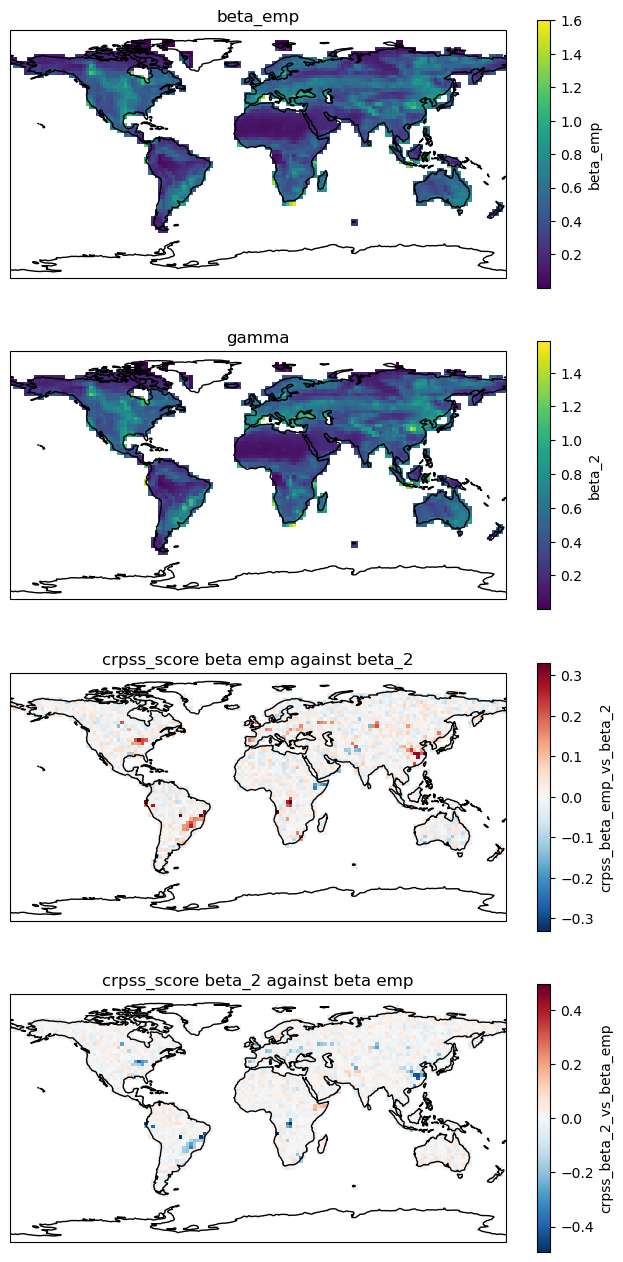

In [22]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
)
depth = 0

da = beta_emp_vs_beta_2.isel(depth=depth).mean("time").beta_emp.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("beta_emp")

da = beta_emp_vs_beta_2.isel(depth=depth).mean("time").beta_2
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("gamma")

da = beta_emp_vs_beta_2.isel(depth=depth).crpss_beta_emp_vs_beta_2.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score beta emp against beta_2")

da = beta_emp_vs_beta_2.isel(depth=depth).crpss_beta_2_vs_beta_emp.clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title("crpss_score beta_2 against beta emp")


Text(0.5, 1.0, 'crpss_score beta_mon_emp against beta emp')

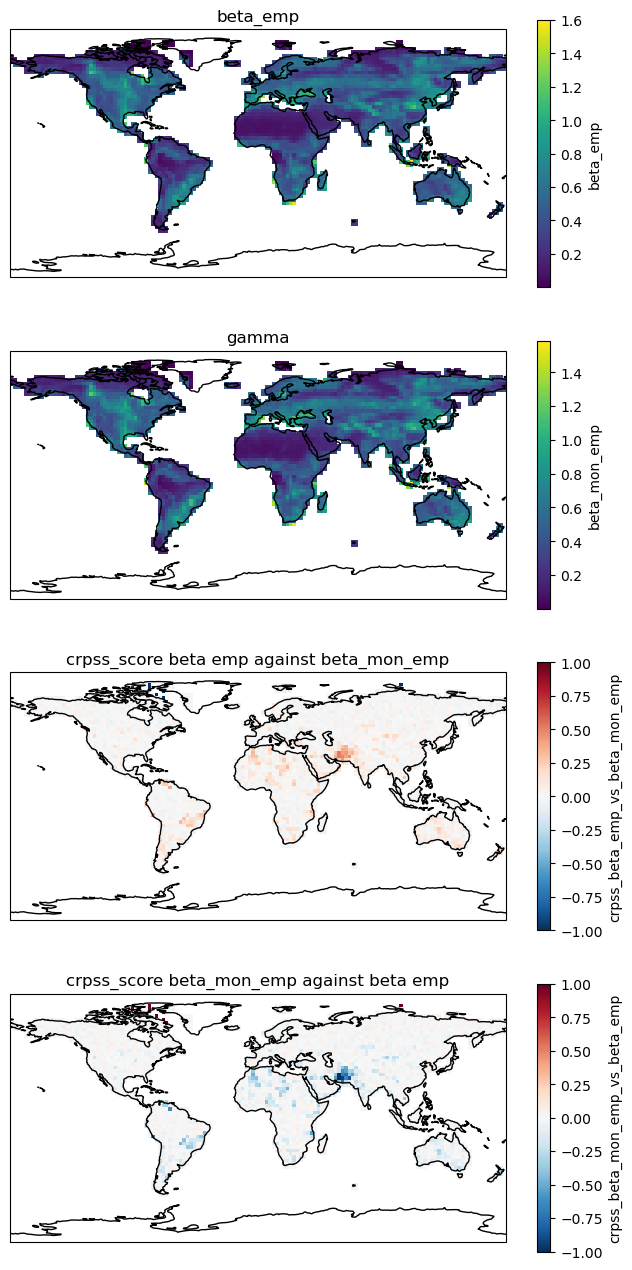

In [23]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
)
depth = 0

da = beta_emp_vs_beta_mon_emp.isel(depth=depth).mean("time").beta_emp.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("beta_emp")

da = beta_emp_vs_beta_mon_emp.isel(depth=depth).mean("time").beta_mon_emp
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("gamma")

da = beta_emp_vs_beta_mon_emp.isel(depth=depth).crpss_beta_emp_vs_beta_mon_emp.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score beta emp against beta_mon_emp")

da = beta_emp_vs_beta_mon_emp.isel(depth=depth).crpss_beta_mon_emp_vs_beta_emp.clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title("crpss_score beta_mon_emp against beta emp")
